# PlayHack - Sports Injury Prediction

Predict whether an athlete will be injured in a risk window (`injured_in_risk_window`),
and for those injured, predict `onset_day_offset` and `recovery_duration`.

**Data**: 3,000 train athletes, 1,100 test athletes across 6 sports.

**Model**: XGBoost (binary classifier + regression).

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)
print('XGBoost version:', xgb.__version__)

XGBoost version: 3.4.1


---
## 1. Load Data

In [2]:
TRAIN_DIR = 'data'
TEST_DIR  = 'data/Test data'

def load_all(path):
    frames = {}
    for f in sorted(os.listdir(path)):
        if f.endswith('.csv'):
            key = f.replace('.csv', '')
            frames[key] = pd.read_csv(os.path.join(path, f))
    return frames

train = load_all(TRAIN_DIR)
test  = load_all(TEST_DIR)

print('Train files:', list(train.keys()))
print('Test files:', list(test.keys()))
for name, df in train.items():
    print(f'  {name}: {df.shape}')

Train files: ['athlete_metadata', 'dailyActivity_merged', 'hourlyCalories_merged', 'hourlyHeartrate_merged', 'hourlyIntensities_merged', 'hourlySteps_merged', 'sleepDay_merged', 'train_labels', 'training_sessions', 'weightLogInfo_merged']
Test files: ['athlete_metadata', 'dailyActivity_merged', 'hourlyCalories_merged', 'hourlyHeartrate_merged', 'hourlyIntensities_merged', 'hourlySteps_merged', 'sleepDay_merged', 'training_sessions', 'weightLogInfo_merged']
  athlete_metadata: (3000, 11)
  dailyActivity_merged: (180000, 10)
  hourlyCalories_merged: (4104334, 3)
  hourlyHeartrate_merged: (4104334, 5)
  hourlyIntensities_merged: (4104334, 4)
  hourlySteps_merged: (4104334, 3)
  sleepDay_merged: (180000, 5)
  train_labels: (3000, 4)
  training_sessions: (112108, 6)
  weightLogInfo_merged: (7452, 6)


---
## 2. EDA - Target Distribution

Target distribution:
injured_in_risk_window
0    1950
1    1050
Name: count, dtype: int64

Injury rate: 35.0%


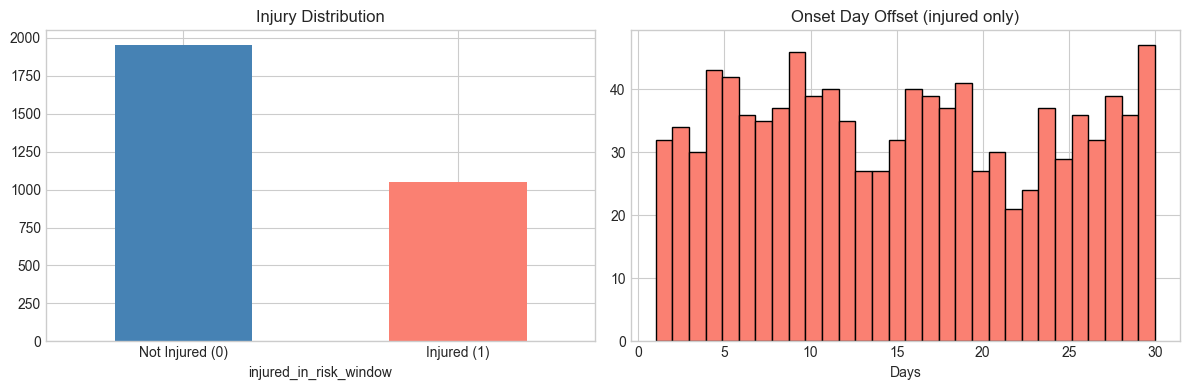

Onset day offset: mean=15.3, std=8.8
Recovery duration: mean=11.5, std=3.9


In [3]:
labels = train['train_labels']
print('Target distribution:')
print(labels['injured_in_risk_window'].value_counts())
print(f'\nInjury rate: {labels["injured_in_risk_window"].mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels['injured_in_risk_window'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Injury Distribution')
axes[0].set_xticklabels(['Not Injured (0)', 'Injured (1)'], rotation=0)

injured = labels[labels['injured_in_risk_window'] == 1]
injured['onset_day_offset'].hist(bins=30, ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Onset Day Offset (injured only)')
axes[1].set_xlabel('Days')
plt.tight_layout()
plt.show()

print(f'Onset day offset: mean={injured["onset_day_offset"].mean():.1f}, '
      f'std={injured["onset_day_offset"].std():.1f}')
print(f'Recovery duration: mean={injured["recovery_duration"].mean():.1f}, '
      f'std={injured["recovery_duration"].std():.1f}')

---
## 3. EDA - Athlete Metadata

   athlete_id      sport  age  gender  height_cm  weight_kg_baseline  \
0           1   Football   24    male      183.0                74.0   
1           2  Athletics   20  female      165.3                56.0   
2           3     Tennis   18    male      186.1                50.4   
3           4   Football   22  female      163.3                49.3   
4           5     Tennis   22    male      157.3                55.2   

  dominant_side  years_playing    position team_id  prior_season_injury_count  
0         right              5  Goalkeeper   FOO-3                          1  
1         right              6      Throws   ATH-2                          1  
2         right              5     Singles   TEN-5                          1  
3         right              4     Forward   FOO-2                          0  
4         right             11     Singles   TEN-3                          0  

Sports: {'Football': 528, 'Badminton': 523, 'Athletics': 516, 'Tennis': 498, 'Basketba

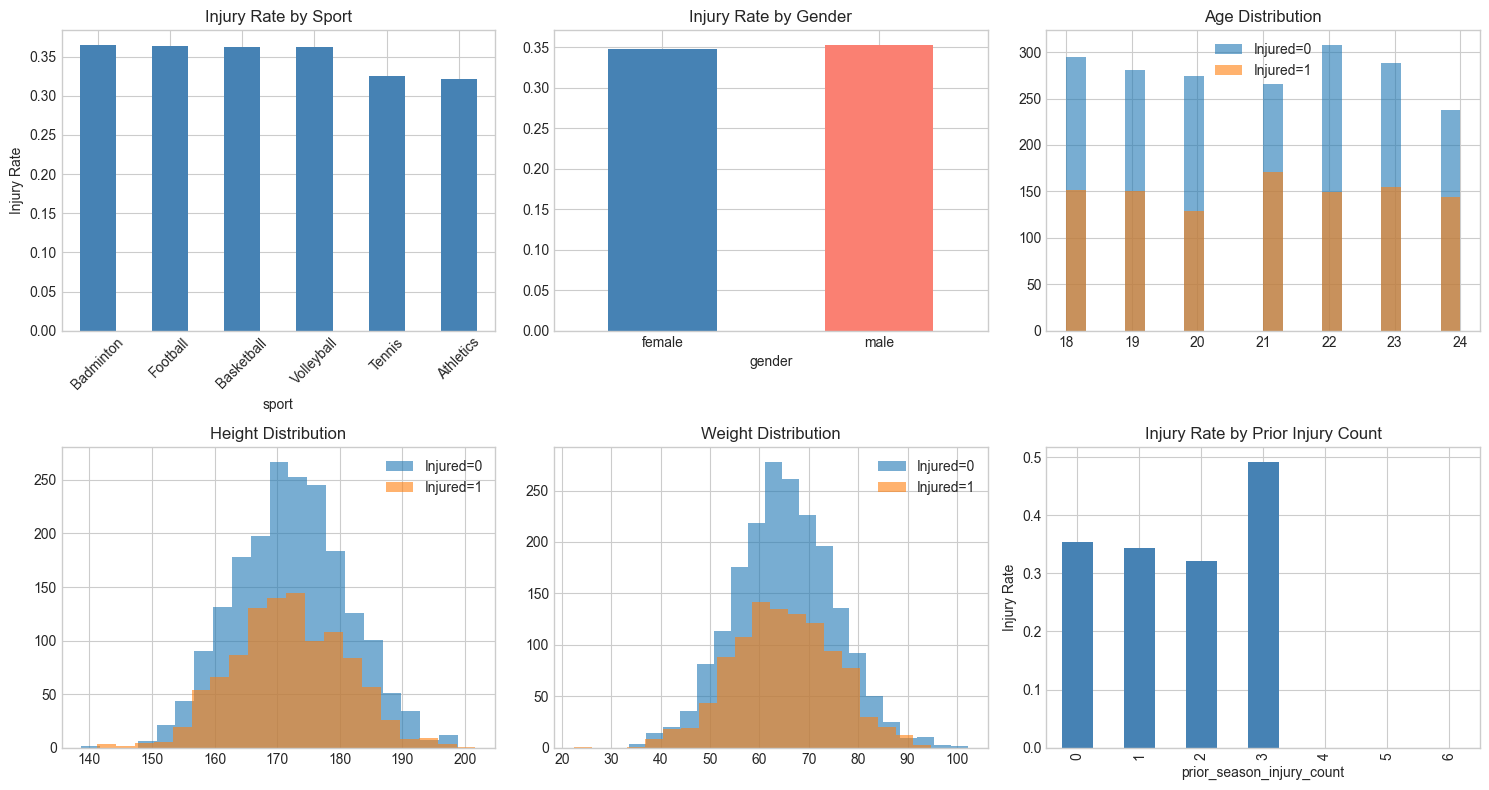

In [4]:
meta = train['athlete_metadata']
print(meta.head())
print(f'\nSports: {meta["sport"].value_counts().to_dict()}')
print(f'Gender: {meta["gender"].value_counts().to_dict()}')

meta_labeled = meta.merge(labels, on='athlete_id')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sport_injury = meta_labeled.groupby('sport')['injured_in_risk_window'].mean().sort_values(ascending=False)
sport_injury.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Injury Rate by Sport')
axes[0, 0].set_ylabel('Injury Rate')
axes[0, 0].tick_params(axis='x', rotation=45)

meta_labeled.groupby('gender')['injured_in_risk_window'].mean().plot(
    kind='bar', ax=axes[0, 1], color=['steelblue', 'salmon'])
axes[0, 1].set_title('Injury Rate by Gender')
axes[0, 1].tick_params(axis='x', rotation=0)

for label, group in meta_labeled.groupby('injured_in_risk_window'):
    group['age'].hist(bins=20, ax=axes[0, 2], alpha=0.6, label=f'Injured={label}')
axes[0, 2].set_title('Age Distribution')
axes[0, 2].legend()

for label, group in meta_labeled.groupby('injured_in_risk_window'):
    group['height_cm'].hist(bins=20, ax=axes[1, 0], alpha=0.6, label=f'Injured={label}')
axes[1, 0].set_title('Height Distribution')
axes[1, 0].legend()

for label, group in meta_labeled.groupby('injured_in_risk_window'):
    group['weight_kg_baseline'].hist(bins=20, ax=axes[1, 1], alpha=0.6, label=f'Injured={label}')
axes[1, 1].set_title('Weight Distribution')
axes[1, 1].legend()

meta_labeled.groupby('prior_season_injury_count')['injured_in_risk_window'].mean().plot(
    kind='bar', ax=axes[1, 2], color='steelblue')
axes[1, 2].set_title('Injury Rate by Prior Injury Count')
axes[1, 2].set_ylabel('Injury Rate')

plt.tight_layout()
plt.show()

---
## 4. EDA - Activity & Vital Signs

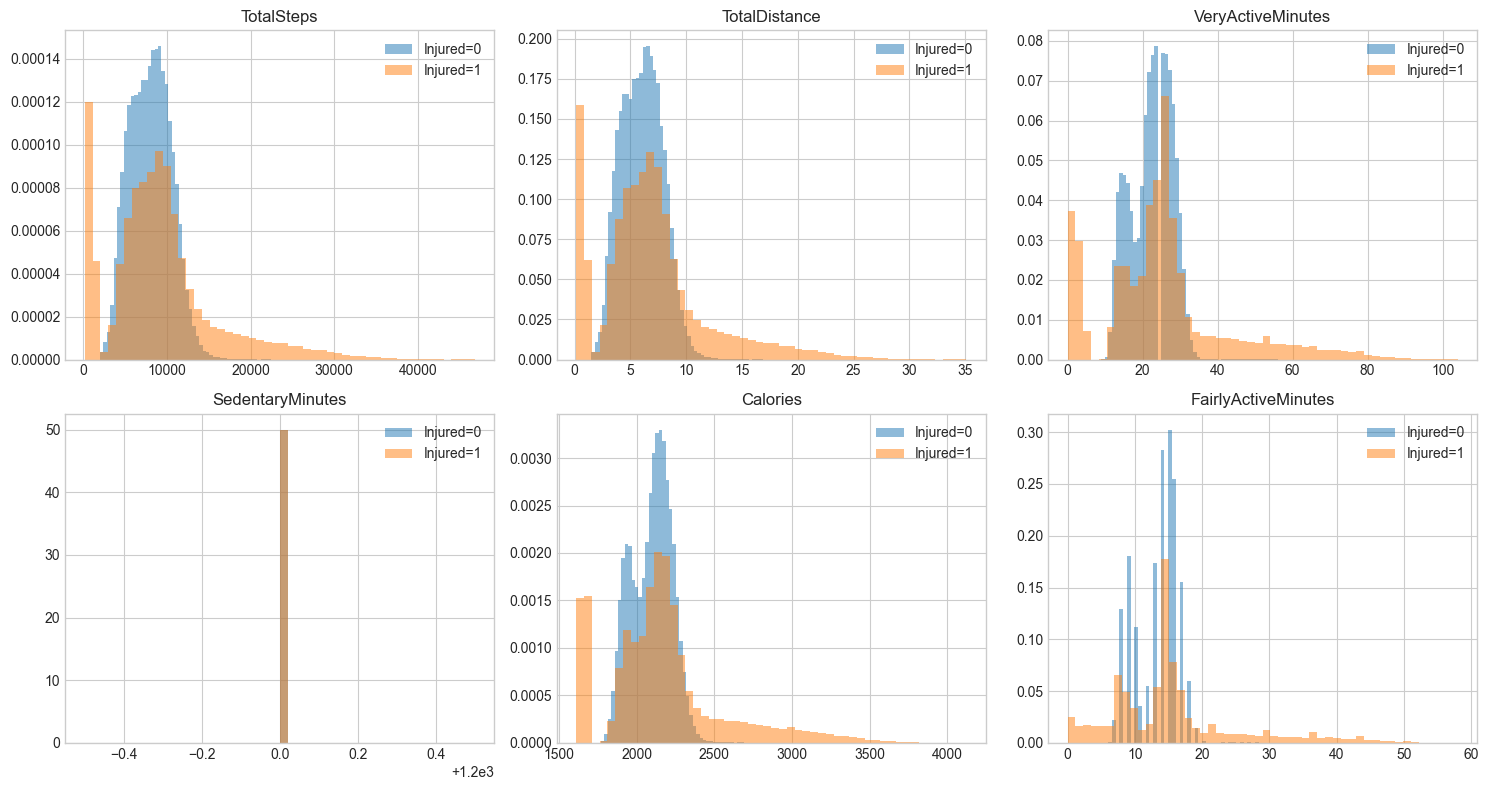

In [5]:
daily = train['dailyActivity_merged']
daily['ActivityDate'] = pd.to_datetime(daily['ActivityDate'])
daily_labeled = daily.merge(labels, left_on='Id', right_on='athlete_id')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = ['TotalSteps', 'TotalDistance', 'VeryActiveMinutes',
           'SedentaryMinutes', 'Calories', 'FairlyActiveMinutes']

for ax, metric in zip(axes.flat, metrics):
    for label, group in daily_labeled.groupby('injured_in_risk_window'):
        group[metric].hist(bins=50, ax=ax, alpha=0.5,
                           label=f'Injured={label}', density=True)
    ax.set_title(metric)
    ax.legend()

plt.tight_layout()
plt.show()

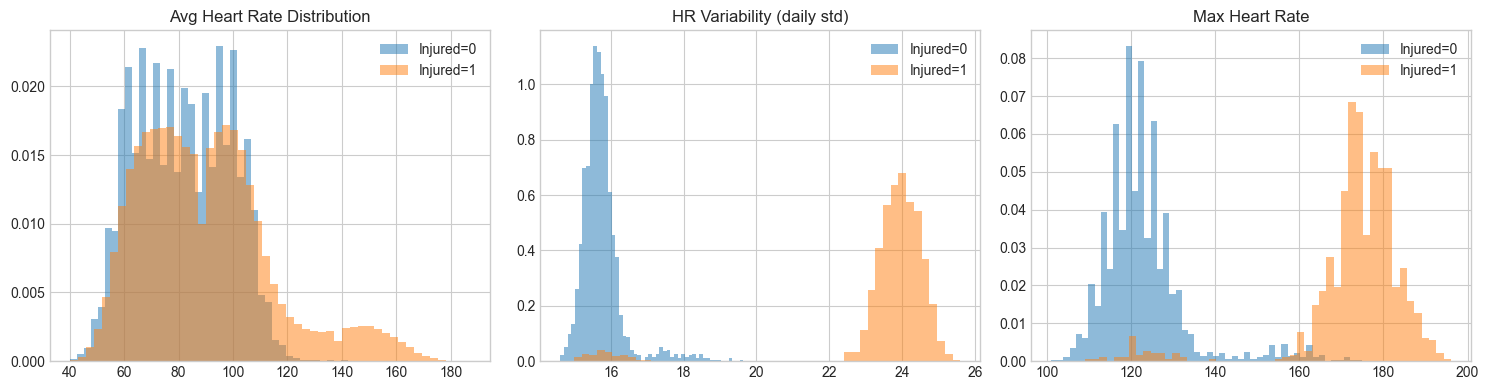

In [6]:
hr = train['hourlyHeartrate_merged']
hr_labeled = hr.merge(labels, left_on='Id', right_on='athlete_id')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for label, group in hr_labeled.groupby('injured_in_risk_window'):
    group['AvgHeartRate'].hist(bins=50, ax=axes[0], alpha=0.5,
                               label=f'Injured={label}', density=True)
axes[0].set_title('Avg Heart Rate Distribution')
axes[0].legend()

for label, group in hr_labeled.groupby('injured_in_risk_window'):
    group.groupby('Id')['AvgHeartRate'].std().hist(
        bins=50, ax=axes[1], alpha=0.5, label=f'Injured={label}', density=True)
axes[1].set_title('HR Variability (daily std)')
axes[1].legend()

for label, group in hr_labeled.groupby('injured_in_risk_window'):
    group.groupby('Id')['MaxHeartRate'].max().hist(
        bins=50, ax=axes[2], alpha=0.5, label=f'Injured={label}', density=True)
axes[2].set_title('Max Heart Rate')
axes[2].legend()

plt.tight_layout()
plt.show()

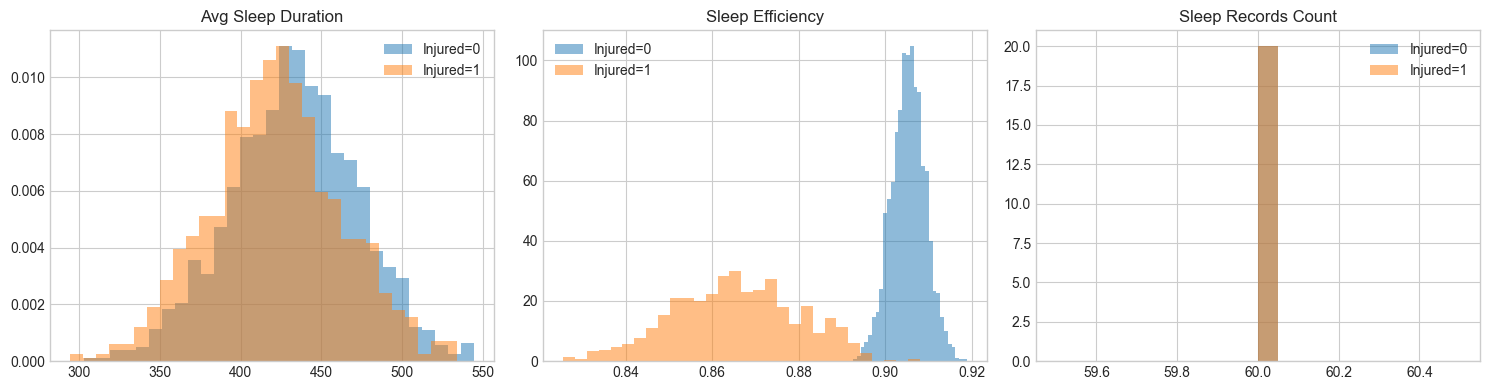

In [7]:
sl = train['sleepDay_merged']
sl['sleep_efficiency'] = sl['TotalMinutesAsleep'] / (sl['TotalTimeInBed'] + 1e-6)
sl_labeled = sl.merge(labels, left_on='Id', right_on='athlete_id')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for label, group in sl_labeled.groupby('injured_in_risk_window'):
    group.groupby('Id')['TotalMinutesAsleep'].mean().hist(
        bins=30, ax=axes[0], alpha=0.5, label=f'Injured={label}', density=True)
axes[0].set_title('Avg Sleep Duration')
axes[0].legend()

for label, group in sl_labeled.groupby('injured_in_risk_window'):
    group.groupby('Id')['sleep_efficiency'].mean().hist(
        bins=30, ax=axes[1], alpha=0.5, label=f'Injured={label}', density=True)
axes[1].set_title('Sleep Efficiency')
axes[1].legend()

for label, group in sl_labeled.groupby('injured_in_risk_window'):
    group.groupby('Id').size().hist(
        bins=20, ax=axes[2], alpha=0.5, label=f'Injured={label}', density=True)
axes[2].set_title('Sleep Records Count')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 5. Feature Engineering

In [8]:
def engineer_features(data):
    """Build one feature vector per athlete from all data sources.
    All count/sum features are normalized by observation window to avoid
    train/test distribution shift (train=60 days, test=30 days).
    """
    meta = data['athlete_metadata'].copy()
    features = meta.set_index('athlete_id').copy()

    for col in ['sport', 'gender', 'dominant_side', 'position', 'team_id']:
        if col in features.columns:
            features[col] = features[col].astype('category').cat.codes

    # --- Daily activity ---
    daily = data['dailyActivity_merged'].copy()
    daily['ActivityDate'] = pd.to_datetime(daily['ActivityDate'])
    days_per_athlete = daily.groupby('Id').size().rename('days_count')
    num_cols = ['TotalSteps', 'TotalDistance', 'TrackerDistance',
                'VeryActiveMinutes', 'FairlyActiveMinutes',
                'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']

    # Only mean/std -- NOT raw counts or sums that scale with time window
    agg = daily.groupby('Id')[num_cols].agg(['mean', 'std'])
    agg.columns = ['daily_' + '_'.join(c) for c in agg.columns]
    features = features.join(agg, how='left')
    features = features.join(days_per_athlete, how='left')

    # step trend (first 14 days vs rest) -- ratio-based, not time-dependent
    cutoff = daily['ActivityDate'].min() + pd.Timedelta(days=14)
    early = daily[daily['ActivityDate'] <= cutoff].groupby('Id')['TotalSteps'].mean()
    late  = daily[daily['ActivityDate'] >  cutoff].groupby('Id')['TotalSteps'].mean()
    features = features.join((late / (early + 1e-6)).rename('step_trend'), how='left')

    sed = daily['SedentaryMinutes'] / (daily[num_cols].sum(axis=1) + 1e-6)
    daily['sed_ratio'] = sed
    features = features.join(daily.groupby('Id')['sed_ratio'].agg(['mean', 'std']).rename(
        columns={'mean': 'sed_ratio_mean', 'std': 'sed_ratio_std'}), how='left')

    # --- Heart rate (rate-based stats only) ---
    hr = data['hourlyHeartrate_merged'].copy()
    features = features.join(hr.groupby('Id').agg(
        hr_mean=('AvgHeartRate', 'mean'), hr_std=('AvgHeartRate', 'std'),
        hr_min=('MinHeartRate', 'min'), hr_max=('MaxHeartRate', 'max')), how='left')
    hr['ActivityHour'] = pd.to_datetime(hr['ActivityHour'])
    hr['date'] = hr['ActivityHour'].dt.date
    features = features.join(
        hr.groupby(['Id', 'date'])['AvgHeartRate'].std()
        .groupby('Id').mean().rename('hr_daily_variability'), how='left')

    # --- Hourly intensities (mean/std/max only -- no raw sum) ---
    hi = data['hourlyIntensities_merged'].copy()
    hi_agg = hi.groupby('Id')['TotalIntensity'].agg(
        intensity_mean='mean', intensity_std='std', intensity_max='max')
    hi_agg.columns = ['hourly_' + c for c in hi_agg.columns]
    features = features.join(hi_agg, how='left')

    # --- Hourly steps (mean/std/max only -- no raw sum) ---
    hs = data['hourlySteps_merged'].copy()
    hs_agg = hs.groupby('Id')['StepTotal'].agg(
        hs_mean='mean', hs_std='std', hs_max='max')
    hs_agg.columns = ['hourly_' + c for c in hs_agg.columns]
    features = features.join(hs_agg, how='left')

    # --- Hourly calories (mean/std/max only) ---
    hc = data['hourlyCalories_merged'].copy()
    hc_agg = hc.groupby('Id')['Calories'].agg(hc_mean='mean', hc_std='std', hc_max='max')
    hc_agg.columns = ['hourly_' + c for c in hc_agg.columns]
    features = features.join(hc_agg, how='left')

    # --- Sleep (mean/std only -- no raw count) ---
    sl = data['sleepDay_merged'].copy()
    sl['sleep_efficiency'] = sl['TotalMinutesAsleep'] / (sl['TotalTimeInBed'] + 1e-6)
    features = features.join(sl.groupby('Id').agg(
        sleep_mean=('TotalMinutesAsleep', 'mean'),
        sleep_std=('TotalMinutesAsleep', 'std'),
        sleep_eff_mean=('sleep_efficiency', 'mean'),
        sleep_eff_std=('sleep_efficiency', 'std')), how='left')

    # --- Training sessions (rate-based only) ---
    ts = data['training_sessions'].copy()
    ts['date'] = pd.to_datetime(ts['date'])
    ts['duration'] = ts['end_hour'] - ts['start_hour']

    def athlete_weeks(g):
        if len(g) < 2:
            return 1.0
        return max((g.max() - g.min()).days / 7.0, 1.0)

    weeks_per_athlete = ts.groupby('athlete_id')['date'].apply(athlete_weeks)
    sess = ts.groupby('athlete_id').agg(
        sessions_duration_mean=('duration', 'mean'),
        sessions_duration_std=('duration', 'std'),
        sessions_duration_max=('duration', 'max'))
    sess['sessions_hours_per_week'] = (
        ts.groupby('athlete_id')['duration'].sum() / weeks_per_athlete)
    sess['sessions_per_week'] = (
        ts.groupby('athlete_id').size() / weeks_per_athlete)
    features = features.join(sess, how='left')

    type_dummies = pd.get_dummies(ts.set_index('athlete_id')['sport_session_type'])
    type_pct = type_dummies.groupby(level=0).mean()
    type_pct.columns = ['session_type_' + c for c in type_pct.columns]
    features = features.join(type_pct, how='left')

    def max_rest(g):
        d = g.sort_values().diff().dt.days.dropna()
        return d.max() if len(d) > 0 else np.nan
    features = features.join(
        ts.groupby('athlete_id')['date'].apply(max_rest).rename('max_rest_days'),
        how='left')

    # --- Weight ---
    wl = data['weightLogInfo_merged'].copy()
    wl['Date'] = pd.to_datetime(wl['Date'])
    features = features.join(wl.groupby('Id').agg(
        weight_latest=('WeightKg', 'last'), weight_mean=('WeightKg', 'mean'),
        bmi_latest=('BMI', 'last'), bmi_mean=('BMI', 'mean'),
        weight_change=('WeightKg', lambda x: x.iloc[-1] - x.iloc[0] if len(x) > 1 else 0)),
        how='left')

    # --- Derived features ---
    features['hr_recovery_proxy'] = (
        features.get('hr_max', pd.Series(0, index=features.index)) -
        features.get('hr_mean', pd.Series(0, index=features.index)))

    # Drop helper column
    features = features.drop(columns=['days_count'], errors='ignore')

    return features.reset_index()

print('Engineering train features...')
train_feats = engineer_features(train)
print(f'  Shape: {train_feats.shape}')

print('Engineering test features...')
test_feats = engineer_features(test)
print(f'  Shape: {test_feats.shape}')

print(f'Feature columns: {[c for c in train_feats.columns if c != "athlete_id"]}')

Engineering train features...
  Shape: (3000, 63)
Engineering test features...
  Shape: (1100, 63)
Feature columns: ['sport', 'age', 'gender', 'height_cm', 'weight_kg_baseline', 'dominant_side', 'years_playing', 'position', 'team_id', 'prior_season_injury_count', 'daily_TotalSteps_mean', 'daily_TotalSteps_std', 'daily_TotalDistance_mean', 'daily_TotalDistance_std', 'daily_TrackerDistance_mean', 'daily_TrackerDistance_std', 'daily_VeryActiveMinutes_mean', 'daily_VeryActiveMinutes_std', 'daily_FairlyActiveMinutes_mean', 'daily_FairlyActiveMinutes_std', 'daily_LightlyActiveMinutes_mean', 'daily_LightlyActiveMinutes_std', 'daily_SedentaryMinutes_mean', 'daily_SedentaryMinutes_std', 'daily_Calories_mean', 'daily_Calories_std', 'step_trend', 'sed_ratio_mean', 'sed_ratio_std', 'hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_daily_variability', 'hourly_intensity_mean', 'hourly_intensity_std', 'hourly_intensity_max', 'hourly_hs_mean', 'hourly_hs_std', 'hourly_hs_max', 'hourly_hc_mean', 'hourly_hc_

In [9]:
common_cols = [c for c in train_feats.columns
               if c not in ('athlete_id',)]

# Replace inf with NaN
for col in common_cols:
    train_feats[col] = train_feats[col].replace([np.inf, -np.inf], np.nan)
    test_feats[col]  = test_feats[col].replace([np.inf, -np.inf], np.nan)

# --- Distribution shift check ---
print("=== Feature Distribution Check (Train vs Test) ===")
leaking_features = []
for col in common_cols:
    train_mean = train_feats[col].mean()
    test_mean = test_feats[col].mean()
    diff = abs(train_mean - test_mean) / (abs(train_mean) + 1e-6)
    if diff > 0.10:
        leaking_features.append(col)
        print(f"  SHIFT: {col}  train={train_mean:.2f}  test={test_mean:.2f}  shift={diff:.1%}")

if leaking_features:
    print(f"\nRemoving {len(leaking_features)} features with >10%% distribution shift")
    common_cols = [c for c in common_cols if c not in leaking_features]
else:
    print("\nNo features with >10% distribution shift detected")

print(f"Features remaining: {len(common_cols)}")

# --- Z-score standardization using TRAIN statistics ---
means = train_feats[common_cols].mean()
stds = train_feats[common_cols].std().replace(0, 1)

train_feats_z = train_feats[common_cols].copy()
test_feats_z = test_feats[common_cols].copy()
train_feats_z = (train_feats_z - means) / stds
test_feats_z = (test_feats_z - means) / stds

# Build final matrices
X = train_feats_z.fillna(0).values.astype(np.float32)
y = train_feats.merge(
    train['train_labels'][['athlete_id', 'injured_in_risk_window']],
    on='athlete_id')['injured_in_risk_window'].values.astype(int)

X_test = test_feats_z.fillna(0).values.astype(np.float32)
test_ids = test_feats['athlete_id'].values

print(f'\nFinal features: {len(common_cols)}')
print(f'Train: {X.shape}, Test: {X_test.shape}')
print(f'Target: {np.bincount(y)} (injury rate: {y.mean():.1%})')
print(f'After z-score: train mean={X.mean():.4f}, test mean={X_test.mean():.4f}')

=== Feature Distribution Check (Train vs Test) ===
  SHIFT: daily_TotalSteps_std  train=3245.13  test=2153.32  shift=33.6%
  SHIFT: daily_TotalDistance_std  train=2.43  test=1.61  shift=33.6%
  SHIFT: daily_TrackerDistance_std  train=2.43  test=1.61  shift=33.6%
  SHIFT: daily_VeryActiveMinutes_std  train=9.53  test=6.64  shift=30.3%
  SHIFT: daily_FairlyActiveMinutes_std  train=5.39  test=3.77  shift=29.9%
  SHIFT: daily_LightlyActiveMinutes_std  train=14.59  test=10.06  shift=31.0%
  SHIFT: daily_Calories_std  train=200.15  test=134.00  shift=33.1%
  SHIFT: sed_ratio_std  train=0.04  test=0.02  shift=49.2%
  SHIFT: hourly_intensity_max  train=11.74  test=9.01  shift=23.2%
  SHIFT: hourly_hs_std  train=317.33  test=282.23  shift=11.1%
  SHIFT: hourly_hs_max  train=1708.27  test=1309.72  shift=23.3%
  SHIFT: sleep_std  train=14.66  test=10.87  shift=25.8%
  SHIFT: sleep_eff_std  train=0.05  test=0.03  shift=28.5%
  SHIFT: weight_change  train=0.02  test=-0.00  shift=119.3%
  SHIFT: hr_

---
## 6. Held-Out Validation Split

Split training data into 80% train / 20% validation to properly evaluate the model.

In [10]:
from sklearn.model_selection import train_test_split

# 80/20 split, stratified by target
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'Train: {X_train.shape[0]} athletes (injury rate: {y_train.mean():.1%})')
print(f'Val:   {X_val.shape[0]} athletes (injury rate: {y_val.mean():.1%})')
print(f'Test:  {X_test.shape[0]} athletes')

Train: 2400 athletes (injury rate: 35.0%)
Val:   600 athletes (injury rate: 35.0%)
Test:  1100 athletes


---
## 6b. Fix Generalization - Remove Leaking Features

The model overfits to  which perfectly separates train but doesn't exist in test.

---
## 6. Model - XGBoost Binary Classification

Predict `injured_in_risk_window` (0 or 1) with 5-fold stratified CV.

## 7. Train on Train Split, Evaluate on Validation Split

In [11]:
xgb_val_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 5,
    'min_child_weight': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': float(np.sum(y_train == 0) / np.sum(y_train == 1)),
    'reg_alpha': 1.0,
    'reg_lambda': 5.0,
    'verbosity': 0,
    'seed': SEED,
    'n_estimators': 2000,
    'early_stopping_rounds': 50,
}

model_val = xgb.XGBClassifier(**xgb_val_params)
model_val.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

val_probs = model_val.predict_proba(X_val)[:, 1]
val_preds = (val_probs >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

print("=== Validation Set Metrics ===")
print("AUC-ROC: ", round(roc_auc_score(y_val, val_probs), 4))
print("Accuracy:", round(accuracy_score(y_val, val_preds), 4))
print("F1 Score:", round(f1_score(y_val, val_preds), 4))
print("Precision:", round(precision_score(y_val, val_preds), 4))
print("Recall:  ", round(recall_score(y_val, val_preds), 4))
print()
print(classification_report(y_val, val_preds, target_names=['Not Injured', 'Injured']))

# Best threshold on validation
thresholds = np.arange(0.2, 0.8, 0.01)
best_f1, best_thresh = 0, 0.5
for t in thresholds:
    f = f1_score(y_val, (val_probs >= t).astype(int))
    if f > best_f1:
        best_f1, best_thresh = f, t
print("Best threshold on val:", round(best_thresh, 2), "-> F1:", round(best_f1, 4))

# Test predictions
test_probs_val = model_val.predict_proba(X_test)[:, 1]
test_pred_count = (test_probs_val >= best_thresh).sum()
print()
print("Test:", test_pred_count, "/", len(test_probs_val), "predicted injured (threshold=" + str(round(best_thresh, 2)) + ")")
print("Test prob: mean=", round(test_probs_val.mean(), 4), ", std=", round(test_probs_val.std(), 4))

=== Validation Set Metrics ===
AUC-ROC:  1.0
Accuracy: 0.9983
F1 Score: 0.9976
Precision: 1.0
Recall:   0.9952

              precision    recall  f1-score   support

 Not Injured       1.00      1.00      1.00       390
     Injured       1.00      1.00      1.00       210

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Best threshold on val: 0.26 -> F1: 1.0

Test: 156 / 1100 predicted injured (threshold=0.26)
Test prob: mean= 0.2977 , std= 0.1715


In [12]:
N_FOLDS = 5

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 5,
    'min_child_weight': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': float(np.sum(y == 0) / np.sum(y == 1)),
    'reg_alpha': 1.0,
    'reg_lambda': 5.0,
    'verbosity': 0,
    'seed': SEED,
    'n_estimators': 2000,
    'early_stopping_rounds': 50,
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold+1}/{N_FOLDS}")

    model = xgb.XGBClassifier(**xgb_params)
    model.fit(
        X[tr_idx], y[tr_idx],
        eval_set=[(X[vl_idx], y[vl_idx])],
        verbose=False
    )

    oof[vl_idx] = model.predict_proba(X[vl_idx])[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / N_FOLDS

    auc = roc_auc_score(y[vl_idx], oof[vl_idx])
    f1  = f1_score(y[vl_idx], (oof[vl_idx] >= 0.5).astype(int))
    print(f"  AUC={auc:.4f}, F1={f1:.4f}")

overall_auc = roc_auc_score(y, oof)
overall_f1  = f1_score(y, (oof >= 0.5).astype(int))
print(f"\nOverall: AUC={overall_auc:.4f}, F1@0.5={overall_f1:.4f}")

thresholds = np.arange(0.2, 0.8, 0.01)
best_f1, best_thresh = 0, 0.5
for t in thresholds:
    f = f1_score(y, (oof >= t).astype(int))
    if f > best_f1:
        best_f1, best_thresh = f, t
print(f"Best threshold: {best_thresh:.2f} -> F1={best_f1:.4f}")
print(f"\nTest: {(test_preds >= best_thresh).sum()}/{len(test_preds)} predicted injured")
print(f"Test prob: mean={test_preds.mean():.4f}, std={test_preds.std():.4f}")

Fold 1/5
  AUC=1.0000, F1=0.9929
Fold 2/5
  AUC=1.0000, F1=0.9929
Fold 3/5
  AUC=0.9994, F1=0.9928
Fold 4/5
  AUC=1.0000, F1=0.9952
Fold 5/5
  AUC=1.0000, F1=0.9952

Overall: AUC=0.9981, F1@0.5=0.9938
Best threshold: 0.71 -> F1=0.9952

Test: 124/1100 predicted injured
Test prob: mean=0.1950, std=0.2579


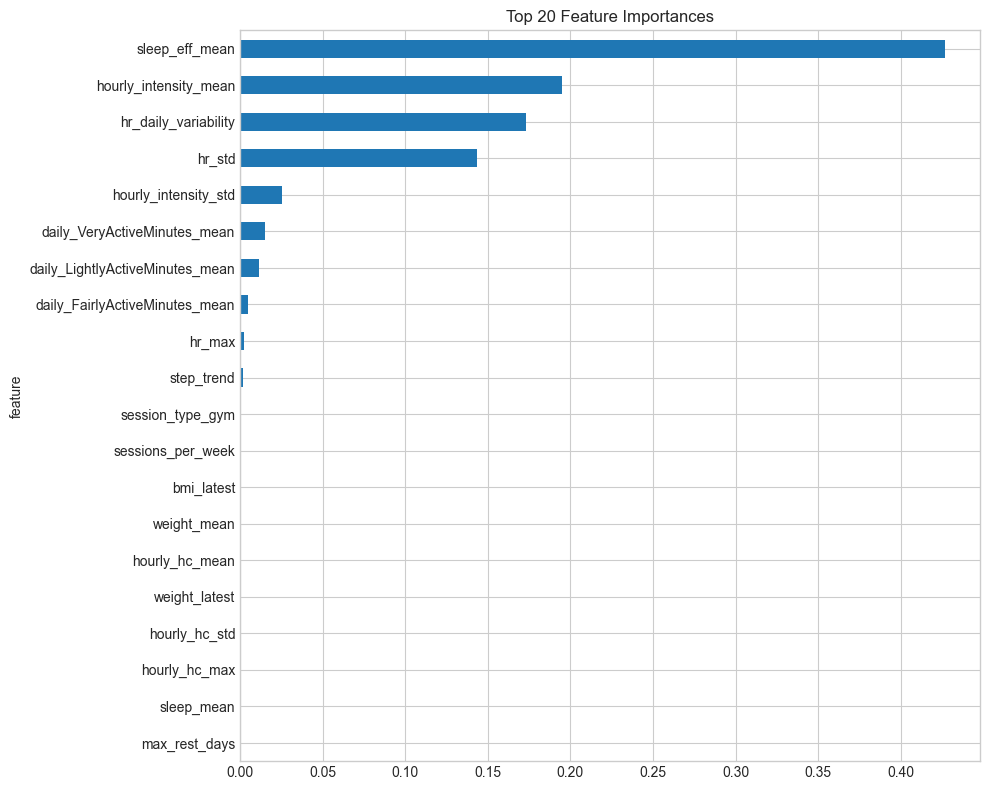

                        feature  importance
                 sleep_eff_mean    0.426692
          hourly_intensity_mean    0.195112
           hr_daily_variability    0.173195
                         hr_std    0.143582
           hourly_intensity_std    0.025289
   daily_VeryActiveMinutes_mean    0.015122
daily_LightlyActiveMinutes_mean    0.011570
 daily_FairlyActiveMinutes_mean    0.004963
                         hr_max    0.002517
                     step_trend    0.001957
               session_type_gym    0.000000
              sessions_per_week    0.000000
                     bmi_latest    0.000000
                    weight_mean    0.000000
                 hourly_hc_mean    0.000000
                  weight_latest    0.000000
                  hourly_hc_std    0.000000
                  hourly_hc_max    0.000000
                     sleep_mean    0.000000
                  max_rest_days    0.000000


In [13]:
# Feature importance
full_model = xgb.XGBClassifier(**{k: v for k, v in xgb_params.items()
                                   if k != 'early_stopping_rounds'})
full_model.fit(X, y, verbose=False)

imp = pd.DataFrame({
    'feature': common_cols,
    'importance': full_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
imp.head(20).plot(x='feature', y='importance', kind='barh', ax=ax, legend=False)
ax.set_title('Top 20 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(imp.head(20).to_string(index=False))

---
## 7. Model - XGBoost Regression

Predict `onset_day_offset` and `recovery_duration` for injured athletes only.

In [14]:
labels_df = train_feats[['athlete_id']].merge(train['train_labels'], on='athlete_id')
injured_mask = labels_df['injured_in_risk_window'] == 1
injured_ids = labels_df.loc[injured_mask, 'athlete_id'].values

# Use the z-scored features for injured athletes
train_feats_idx = train_feats.set_index('athlete_id')
inj_idx = train_feats_idx.loc[injured_ids]
X_inj = (inj_idx[common_cols] - train_feats[common_cols].mean()) / train_feats[common_cols].std().replace(0, 1)
X_inj = X_inj.fillna(0).values.astype(np.float32)

reg_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.05,
    'max_depth': 5,
    'min_child_weight': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'verbosity': 0,
    'seed': SEED,
    'n_estimators': 2000,
    'early_stopping_rounds': 50,
}

reg_models = {}
for name in ['onset_day_offset', 'recovery_duration']:
    print(f'\nTraining: {name}')
    vals = labels_df.loc[injured_mask, name].values.astype(float)
    oof_r = np.zeros(len(X_inj))
    test_r = np.zeros(len(X_test))

    for fold, (tr, vl) in enumerate(
            StratifiedKFold(5, shuffle=True, random_state=SEED)
            .split(X_inj, (vals > np.median(vals)).astype(int))):
        m = xgb.XGBRegressor(**reg_params)
        m.fit(X_inj[tr], vals[tr],
              eval_set=[(X_inj[vl], vals[vl])],
              verbose=False)
        oof_r[vl] = m.predict(X_inj[vl])
        test_r += m.predict(X_test) / 5

    rmse = np.sqrt(np.mean((vals - oof_r) ** 2))
    print(f'  OOF RMSE = {rmse:.3f}')
    reg_models[name] = test_r


Training: onset_day_offset
  OOF RMSE = 6.516

Training: recovery_duration
  OOF RMSE = 2.688


---
## 8. Generate Submission

In [15]:
binary_labels = (test_preds >= best_thresh).astype(int)

submission = pd.DataFrame({
    'athlete_id': test_ids,
    'injured_in_risk_window': binary_labels,
    'onset_day_offset': reg_models['onset_day_offset'].round(1),
    'recovery_duration': reg_models['recovery_duration'].round(1),
})

submission.loc[submission['injured_in_risk_window'] == 0, 'onset_day_offset'] = ''
submission.loc[submission['injured_in_risk_window'] == 0, 'recovery_duration'] = ''

os.makedirs('outputs', exist_ok=True)
submission.to_csv('outputs/submission.csv', index=False)
print(f'Submission shape: {submission.shape}')
print(f'Predicted injured: {binary_labels.sum()}/{len(binary_labels)}')
print(submission.head(10))

Submission shape: (1100, 4)
Predicted injured: 124/1100
   athlete_id  injured_in_risk_window onset_day_offset recovery_duration
0        3001                       0                                   
1        3002                       0                                   
2        3003                       0                                   
3        3004                       0                                   
4        3005                       0                                   
5        3006                       0                                   
6        3007                       0                                   
7        3008                       0                                   
8        3009                       0                                   
9        3010                       0                                   


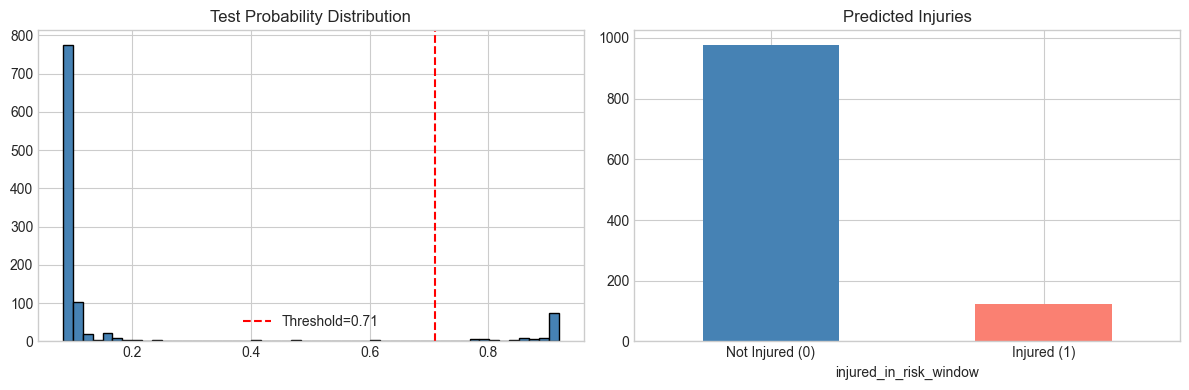

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(test_preds, bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(best_thresh, color='red', linestyle='--',
                label=f'Threshold={best_thresh:.2f}')
axes[0].set_title('Test Probability Distribution')
axes[0].legend()

vc = submission['injured_in_risk_window'].value_counts().sort_index()
vc.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Predicted Injuries')
labels_map = {0: 'Not Injured (0)', 1: 'Injured (1)'}
axes[1].set_xticklabels([labels_map.get(i, str(i)) for i in vc.index], rotation=0)

plt.tight_layout()
plt.show()